[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mansamoussa/zebrAssist/blob/master/notebooks/3_DetectThenClassify_YOLO_SWIN.ipynb)

# Detect → Crop → Classify (YOLOv10 + SWIN)

This notebook loads:
- a **YOLO** detector (best.pt) to find pedestrian traffic lights in an input image,
- a **Swin Transformer** classifier (best_swin.pth) to classify the **largest** detected light into `red / yellow / green`.

Update the paths in the **Config** cell, then run the **Pipeline** cell.

In [1]:
# Install dependencies (safe on Colab; no-op locally if already installed)
try:
    import google.colab  # noqa
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)
if IN_COLAB:
    !pip -q install --upgrade ultralytics timm

Running on Colab: False


In [2]:
import os, random, time
from pathlib import Path
import numpy as np
import torch
from ultralytics import YOLO
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import json
from datetime import datetime
from pathlib import Path
import numpy as np

/Users/mothiam/Documents/Mouha Perso/HSLU/Semester3/Computer_vision/Project/zebrAssist/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Device (CUDA, MPS, or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


In [36]:
# ------------------ CONFIG ------------------
# Path to trained YOLO weights (created by the YOLO notebook)
# Path to trained SWIN checkpoint dict (created by the SWIN notebook)
if IN_COLAB:
  YOLO_BEST = "/content/drive/MyDrive/Computer_Vision_Project/trained_models/1_Yolo_FineTuned/weights/best.pt"
  SWIN_BEST = "/content/drive/MyDrive/Computer_Vision_Project/trained_models/2_Swin_FineTuned/best_swin.pth"
else:
  YOLO_BEST = '/Users/mothiam/Library/CloudStorage/GoogleDrive-mouhamadou.thiam@stud.hslu.ch/Mon Drive/Computer_Vision_Project/runs/pedestrian_lights/imgsz_896_20250922_183214/weights/best.pt'
  # SWIN_BEST = '/Users/mothiam/Library/CloudStorage/GoogleDrive-mouhamadou.thiam@stud.hslu.ch/Mon Drive/Computer_Vision_Project/runs/swin_lights/20250923_210905_baseline.pth'
  SWIN_BEST = '/Users/mothiam/Library/CloudStorage/GoogleDrive-mouhamadou.thiam@stud.hslu.ch/Mon Drive/Computer_Vision_Project/runs/swin_lights/20250925_192601_low_lr.pth'

# Chec if paths exist
assert Path(YOLO_BEST).exists(), f"YOLO weights not found at {YOLO_BEST}"
assert Path(SWIN_BEST).exists(), f"SWIN checkpoint not found at {SWIN_BEST}"

# SWIN model name + input size (should match what you trained with)
SWIN_MODEL_NAME = "swin_tiny_patch4_window7_224"
SWIN_IMG_SIZE   = 224

SWIN_CLASSES = ["green", "red", "yellow"]
# ------------------------------------------------------

In [ ]:
def load_yolo(model_path: str):
    if not Path(model_path).exists():
        raise FileNotFoundError(f"YOLO weights not found: {model_path}")
    return YOLO(model_path)

def load_swin(ckpt_path: str, model_name: str, num_classes: int = 3, img_size: int = 224):
    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"SWIN checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)
    classes = SWIN_CLASSES
    model_name = ckpt.get("model_name", model_name)
    img_size = ckpt.get("img_size", img_size)
    model = timm.create_model(model_name, pretrained=False, num_classes=len(classes))
    model.load_state_dict(ckpt["model"] if "model" in ckpt else ckpt)
    model.to(device).eval()

    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return model, classes, tfm, img_size

In [26]:
def crop_largest_detection(image_path, yolo_model, conf=0.25, iou=0.5, classes=None):
    """
    Returns (crop_pil_rgb, meta_dict, annotated_bgr)
    - crop_pil_rgb: PIL.Image of the largest detection (or None)
    - meta_dict: {'class_id','class_name','confidence','bbox_xyxy','area','image_size'}
    - annotated_bgr: numpy array from YOLO's .plot() for visualization
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    results = yolo_model(str(image_path), conf=conf, iou=iou, classes=classes, verbose=False)
    r = results[0]
    annotated_bgr = r.plot()

    if r.boxes is None or len(r.boxes) == 0:
        return None, None, annotated_bgr

    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    boxes = r.boxes
    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    cls_ids = boxes.cls.cpu().numpy().astype(int)

    # areas after clamping
    xyxy_clamped = np.stack([
        np.clip(xyxy[:,0], 0, W-1),
        np.clip(xyxy[:,1], 0, H-1),
        np.clip(xyxy[:,2], 0, W-1),
        np.clip(xyxy[:,3], 0, H-1),
    ], axis=1)

    widths  = (xyxy_clamped[:,2] - xyxy_clamped[:,0]).clip(min=0)
    heights = (xyxy_clamped[:,3] - xyxy_clamped[:,1]).clip(min=0)
    areas   = widths * heights
    idx = int(np.argmax(areas))
    if areas[idx] <= 0:
        return None, None, annotated_bgr

    x1, y1, x2, y2 = xyxy_clamped[idx].astype(int)
    crop = img.crop((x1, y1, x2, y2))

    class_name = yolo_model.names[int(cls_ids[idx])] if isinstance(yolo_model.names, (list,dict)) else str(int(cls_ids[idx]))

    meta = {
        "class_id": int(cls_ids[idx]),
        "class_name": class_name,
        "confidence": float(confs[idx]),
        "bbox_xyxy": [int(x1), int(y1), int(x2), int(y2)],
        "area": int(areas[idx]),
        "image_size": [W, H],
    }
    return crop, meta, annotated_bgr

In [ ]:
def run_inference_on_images(image_paths, yolo_model, swin_model, swin_tfm, swin_classes, device, conf_threshold=0.8):
    results = []

    for img_path in image_paths:
        print("="*60)
        print(f"Processing: {img_path}")

        # Detect + crop
        crop, meta, annotated_bgr = crop_largest_detection(img_path, yolo_model, conf=0.35, iou=0.5, classes=None)

        # Show YOLO annotated image
        plt.figure(figsize=(6,4))
        plt.imshow(annotated_bgr[..., ::-1])
        plt.axis('off')
        plt.title(f"YOLO detections: {Path(img_path).name}")
        plt.show()

        if crop is None:
            print("No pedestrian light detected with current thresholds.")
            results.append({"image": img_path, "detected": False})
            continue

        # SWIN classification
        x = swin_tfm(crop).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = swin_model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        pred_idx = int(np.argmax(probs))
        pred_class = swin_classes[pred_idx]

        # Show crop + prediction
        plt.figure(figsize=(3,3))
        plt.imshow(crop)
        plt.axis('off')
        plt.title(f"Pred: {pred_class} | p={probs[pred_idx]:.2f}")
        plt.show()

        # Walk / Don't Walk decision
        if pred_class == "green" and probs[pred_idx] > conf_threshold:
            decision = "Walk"
        elif pred_class in ["red", "yellow"] and probs[pred_idx] > conf_threshold:
            decision = "Don't Walk"
        else:
            decision = "No light detected"

        print("Detection meta:", json.dumps(meta, indent=4))
        print("Class probabilities:", json.dumps(
            {swin_classes[i]: float(probs[i]) for i in range(len(swin_classes))}, indent=4))
        print("-> Decision:", decision)

        results.append({
            "image": img_path,
            "detected": True,
            "prediction": pred_class,
            "prob": float(probs[pred_idx]),
            "decision": decision,
            "probs": {swin_classes[i]: float(probs[i]) for i in range(len(swin_classes))}
        })

    return results


In [40]:
# Load models
yolo = load_yolo(YOLO_BEST)
swin, swin_classes, swin_tfm, swin_size = load_swin(SWIN_BEST, SWIN_MODEL_NAME)

In [44]:
TARGET_CLASS_NAME = "pedestrian_traffic_light"
# Get YOLO target class id
names = yolo.names  # dict {id: class_name}
target_cls_id = None
for k,v in names.items():
    if v == TARGET_CLASS_NAME:
        target_cls_id = k
        break

if target_cls_id is None:
    raise ValueError(f"Class '{TARGET_CLASS_NAME}' not found in YOLO model classes: {names}")
print(f"Using YOLO class '{TARGET_CLASS_NAME}' with id {target_cls_id}")

Using YOLO class 'pedestrian_traffic_light' with id 0


Processing: ../data/ZebrAssistSwiss_YOLO_120/val/images/IMG_0006_jpeg.rf.6fce363a7be7799eb7209304a978c5cb.jpg


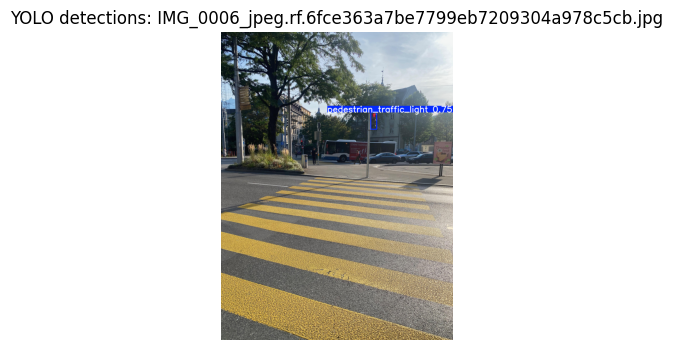

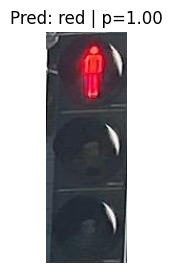

Detection meta: {
    "class_id": 0,
    "class_name": "pedestrian_traffic_light",
    "confidence": 0.7502181529998779,
    "bbox_xyxy": [
        1952,
        1051,
        2029,
        1272
    ],
    "area": 16993,
    "image_size": [
        3024,
        4032
    ]
}
Class probabilities: {
    "green": 0.00017236803250852972,
    "red": 0.999797523021698,
    "yellow": 3.0123866963549517e-05
}
-> Decision: Don't Walk
Processing: ../data/PTL_Dataset_4032x3024_Part1/heon_IMG_0634.JPG


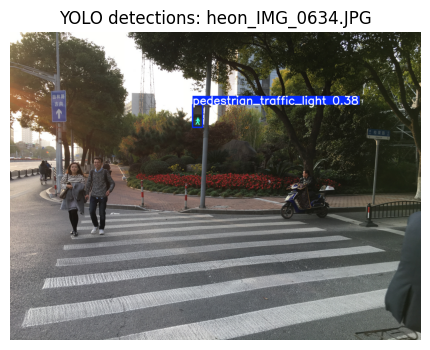

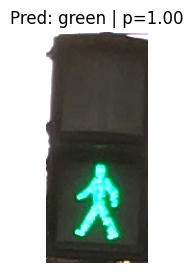

Detection meta: {
    "class_id": 0,
    "class_name": "pedestrian_traffic_light",
    "confidence": 0.38383135199546814,
    "bbox_xyxy": [
        1791,
        712,
        1889,
        935
    ],
    "area": 21858,
    "image_size": [
        4032,
        3024
    ]
}
Class probabilities: {
    "green": 0.9997225403785706,
    "red": 0.00012115912250010297,
    "yellow": 0.00015618592442478985
}
-> Decision: Walk


In [50]:
# Example usage:
if IN_COLAB:
    image_list = [
        "/content/drive/MyDrive/Computer_Vision_Project/data/frames/train/img1.JPG",
        "/content/drive/MyDrive/Computer_Vision_Project/data/frames/train/img3.JPG"
    ]
else:
    image_list = [
        "../data/ZebrAssistSwiss_YOLO_120/val/images/IMG_0006_jpeg.rf.6fce363a7be7799eb7209304a978c5cb.jpg",
        "../data/PTL_Dataset_4032x3024_Part1/heon_IMG_0634.JPG"
    ]

results = run_inference_on_images(image_list, yolo, swin, swin_tfm, swin_classes, device)

In [ ]:
# ================================
# TO RUN LOCALLY - NOT IN COLAB
# YOLOv10 + SWIN realtime video loop + ZEBRA gate (yellow stripes)
# Exit LIGHT mode only if YOLO light is lost for N seconds
# ================================
import os, time, signal
from pathlib import Path
import numpy as np
import torch
import cv2
from ultralytics import YOLO
import timm
from torchvision import transforms
from PIL import Image

# -------- CONFIG (EDIT THESE) --------
if IN_COLAB:
  VIDEO_SRC = '/content/drive/MyDrive/Computer_Vision_Project/data/videos/MVI_Grenchen.MP4' # use mp4 that OpenCV can read easily
else :
  VIDEO_SRC = '../data/videos/MVI_Grenchen.mp4' # use mp4 that OpenCV can read easily

# Video timestamp like 2025-09-21_15-42-10
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
OUT_PATH = f'{Path(VIDEO_SRC).with_suffix("")}_{timestamp}.mp4'

TARGET_CLASS_NAME = "pedestrian_traffic_light"

# Thresholds & pacing YOLO
YOLO_CONF       = 0.4
YOLO_IOU        = 0.50
YOLO_IMGSZ      = 640

DECISION_PERIOD = 0.1         # seconds between YOLO+SWIN runs

DECISION_CONF   = 0.65
SHOW            = True
SAVE            = True
OUT_PATH        = "../data/videos/MVI_Grenchen_processed.mp4"

# --- ZEBRA GATE (yellow stripes) ---
ZEBRA_ROI_REL       = (0.45, 0.95, 0.15, 0.85)  # (ymin,ymax,xmin,xmax) as fractions of H,W (lower-middle)
ZEBRA_CHECK_PERIOD  = 0.25                      # run zebra detector every 0.25s (fast)
ZEBRA_OK_FOR_SEC    = 1.5                       # if found, keep gate open for this long
ZEBRA_MIN_WIDTH_FR  = 0.25                      # zebra bbox must be at least this fraction of image width
ZEBRA_ANGLE_TOL_DEG = 25                        # stripes ~ horizontal within ±deg

# --- state machine knobs ---
# (The older LIGHT_LOST_TIMEOUT rule is removed.)
YOLO_LOST_TIMEOUT = 3.0          # <-- Exit LIGHT mode only if YOLO light disappears for this long
LIGHT_CONF = DECISION_CONF

# -------------------------------------

def swin_predict_rgb(rgb_np: np.ndarray):
    """rgb_np: HxWx3 uint8 RGB. Returns (pred_class, pred_prob)."""
    with torch.no_grad():
        x = swin_tfm(Image.fromarray(rgb_np)).unsqueeze(0).to(device)
        probs = torch.softmax(swin(x), dim=1).cpu().numpy()[0]
    idx = int(np.argmax(probs))
    return swin_classes[idx], float(probs[idx])

def crop_largest_bgr(frame_bgr: np.ndarray, yolo_results, class_filter=None, conf_thr=0.0):
    """Pick largest-area detection. Return (crop_bgr, (x1,y1,x2,y2), det_conf, det_clsid) or (None, None, None, None)."""
    r = yolo_results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return None, None, None, None
    H, W = frame_bgr.shape[:2]
    boxes = r.boxes
    xyxy  = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    clsid = boxes.cls.cpu().numpy().astype(int)

    keep = confs >= conf_thr
    if class_filter is not None:
        keep &= (clsid == class_filter)
    if not np.any(keep):
        return None, None, None, None

    xyxy  = xyxy[keep]
    confs = confs[keep]
    clsid = clsid[keep]

    x1 = np.clip(xyxy[:,0], 0, W-1); y1 = np.clip(xyxy[:,1], 0, H-1)
    x2 = np.clip(xyxy[:,2], 0, W-1); y2 = np.clip(xyxy[:,3], 0, H-1)
    areas = np.maximum(0, x2-x1) * np.maximum(0, y2-y1)
    if areas.size == 0 or areas.max() <= 0:
        return None, None, None, None

    j = int(np.argmax(areas))
    x1,y1,x2,y2 = int(x1[j]), int(y1[j]), int(x2[j]), int(y2[j])
    return frame_bgr[y1:y2, x1:x2].copy(), (x1,y1,x2,y2), float(confs[j]), int(clsid[j])

# ---------- Zebra crossing detector (YELLOW stripes) ----------
def detect_zebra_crossing(
    frame_bgr: np.ndarray,
    roi_rel=(0.45, 0.95, 0.15, 0.85),  # (ymin, ymax, xmin, xmax) in [0,1]
    min_width_frac=0.25,
    angle_accept_deg=25,
) -> tuple[bool, float | None, np.ndarray | None]:
    """
    Returns (found, angle_deg, zebra_poly). Angle is 0=horizontal (±).
    """
    H, W = frame_bgr.shape[:2]
    y0 = int(roi_rel[0]*H); y1 = int(roi_rel[1]*H)
    x0 = int(roi_rel[2]*W); x1 = int(roi_rel[3]*W)
    roi = frame_bgr[y0:y1, x0:x1]

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    # --- YELLOW mask (tune if needed) ---
    # Hue ~15-35, sat >=80, val >=150 (good default for yellow road paint)
    yellow_mask = cv2.inRange(hsv, (15, 80, 150), (35, 255, 255))

    # Clean up
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Edges/lines
    edges = cv2.Canny(mask, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80,
                            minLineLength=max(20, roi.shape[1]//8), maxLineGap=10)
    if lines is None:
        return False, None, None
    lines = lines[:,0,:]  # (N,4)

    angs = []
    for x1_,y1_,x2_,y2_ in lines:
        dx = x2_-x1_; dy = y2_-y1_
        L = np.hypot(dx, dy)
        if L < 10:
            continue
        ang = np.degrees(np.arctan2(dy, dx))  # 0=horizontal
        if ang > 90: ang -= 180
        if ang < -90: ang += 180
        angs.append(ang)
    if not angs:
        return False, None, None

    angs = np.array(angs)
    sel = np.abs(angs) <= angle_accept_deg
    if sel.sum() < 6:  # need enough near-horizontal segments
        return False, None, None

    dom_angle = float(np.median(angs[sel]))

    # Biggest yellow region bbox as zebra proxy
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return False, None, None
    cnt = max(cnts, key=cv2.contourArea)
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect).astype(int)
    box[:,0] += x0; box[:,1] += y0

    # width constraint (must be "in front")
    bbox_w = max(np.linalg.norm(box[0]-box[1]), np.linalg.norm(box[1]-box[2]))
    if bbox_w < min_width_frac * W:
        return False, None, None

    return True, dom_angle, box

# ---------- Open video ----------
cap = cv2.VideoCapture(VIDEO_SRC)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video source: {VIDEO_SRC}")

src_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
delay   = max(1, int(1000 / src_fps))
w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Source: {VIDEO_SRC} | FPS: {src_fps:.1f} | Size: {w}x{h}")

writer = None
if SAVE:
    Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
    # fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    # writer = cv2.VideoWriter(OUT_PATH, fourcc, src_fps, (w, h))
    fourcc = cv2.VideoWriter_fourcc(*"avc1")  # H.264
    writer = cv2.VideoWriter(OUT_PATH, fourcc, src_fps, (w, h))


win = "YOLO+SWIN (realtime look)"
if SHOW:
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)

# graceful Ctrl+C
stop = {"flag": False}
def _sigint(_a,_b): stop["flag"] = True
signal.signal(signal.SIGINT, _sigint)

# ---------- Realtime loop ----------
STATE_SEARCH_ZEBRA = 0
STATE_LIGHT_MODE   = 1
state = STATE_SEARCH_ZEBRA

last_decision = "No light detected"
last_color    = (20,20,20)
last_box      = None
last_prob     = 0.0

# Zebra entry bookkeeping
zebra_last_check = 0.0

# Light cadence & YOLO recency (for exit rule)
last_infer_t    = 0.0            # last YOLO+SWIN inference time
yolo_seen       = False          # have we seen the light (YOLO) since entering LIGHT mode?
last_yolo_time  = 0.0            # last time YOLO detected the light

t0        = time.time()
frame_idx = 0

try:
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        frame_idx += 1
        now = time.time()

        if state == STATE_SEARCH_ZEBRA:
            # Gate: only used to enter LIGHT_MODE
            if (now - zebra_last_check) >= ZEBRA_CHECK_PERIOD:
                zebra_ok, zebra_angle, zebra_poly = detect_zebra_crossing(
                    frame_bgr,
                    roi_rel=ZEBRA_ROI_REL,
                    min_width_frac=ZEBRA_MIN_WIDTH_FR,
                    angle_accept_deg=ZEBRA_ANGLE_TOL_DEG,
                )
                zebra_last_check = now
                if zebra_ok:
                    state = STATE_LIGHT_MODE
                    # reset light status on entry
                    last_box = None
                    last_decision, last_color, last_prob = "No light detected", (20,20,20), 0.0
                    yolo_seen = False
                    last_yolo_time = 0.0
            
            text = "ZEBRA SEARCH... - LIGHT MODE OFF"
            (font_w, font_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)
            zebra_txt_x = (w - font_w) // 2
            zebra_txt_y = h - (h // 8)
            cv2.putText(frame_bgr, text, (zebra_txt_x, zebra_txt_y), cv2.FONT_HERSHEY_SIMPLEX, 1, (220,220,220), 2, cv2.LINE_AA)

        elif state == STATE_LIGHT_MODE:
            # Run light inference at cadence
            if (now - last_infer_t) >= DECISION_PERIOD:
                yres = yolo(frame_bgr, conf=YOLO_CONF, iou=YOLO_IOU, imgsz=YOLO_IMGSZ, verbose=False)
                crop_bgr, bbox, dconf, did = crop_largest_bgr(
                    frame_bgr, yres, class_filter=target_cls_id, conf_thr=YOLO_CONF
                )

                # Record YOLO presence (independent of SWIN color)
                if crop_bgr is not None and crop_bgr.size > 0:
                    yolo_seen = True
                    last_yolo_time = now

                    # Classify the detected light
                    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
                    pred_class, pred_prob = swin_predict_rgb(crop_rgb)

                    if pred_class == "green" and pred_prob >= DECISION_CONF:
                        last_decision, last_color = "Walk", (0,200,0)
                        last_box, last_prob = bbox, pred_prob
                    elif pred_class in ("red","yellow") and pred_prob >= DECISION_CONF:
                        last_decision, last_color = "Don't Walk", (0,0,220)
                        last_box, last_prob = bbox, pred_prob
                    # else: keep previous decision
                else:
                    # No YOLO detection this cycle; keep previous decision
                    pass

                last_infer_t = now

            # Exit condition: YOLO light missing for YOLO_LOST_TIMEOUT (but only after we've seen it at least once)
            yolo_recent = (now - last_yolo_time) <= YOLO_LOST_TIMEOUT if yolo_seen else True
            if not yolo_recent:
                state = STATE_SEARCH_ZEBRA
                last_box = None
                last_decision, last_color, last_prob = "No light detected", (20,20,20), 0.0
                yolo_seen = False
                last_yolo_time = 0.0
            
            # Overlay for Zebra Detected (centered)
            text = "ZEBRA DETECTED - LIGHT MODE ON"
            (font_w, font_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)
            cv2.putText(frame_bgr, text, (zebra_txt_x, zebra_txt_y), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,200,200), 3, cv2.LINE_AA)


        # ---- Common overlays (box + decision + FPS) ----
        if last_box is not None:
            x1,y1,x2,y2 = last_box
            cv2.rectangle(frame_bgr, (x1,y1), (x2,y2), last_color, 2)

        (font_w, font_h), baseline = cv2.getTextSize(last_decision, cv2.FONT_HERSHEY_SIMPLEX, 2, 4)
        pos_x = (w - font_w) // 2
        pos_y = (h // 8)
        cv2.putText(frame_bgr, last_decision, (pos_x, pos_y), cv2.FONT_HERSHEY_SIMPLEX, 2, last_color, 4, cv2.LINE_AA)

        if writer is not None:
            writer.write(frame_bgr)

        if SHOW:
            cv2.imshow(win, frame_bgr)
            if cv2.getWindowProperty(win, cv2.WND_PROP_VISIBLE) < 1:
                break
            key = cv2.waitKey(max(1, int(1000 / src_fps))) & 0xFF
            if key in (27, ord('q')):
                break

finally:
    try: cap.release()
    except: pass
    try:
        if writer is not None: writer.release()
    except: pass
    try:
        if SHOW:
            cv2.destroyWindow(win)
            for _ in range(3): cv2.waitKey(1)
        cv2.destroyAllWindows()
        for _ in range(3): cv2.waitKey(1)
    except: pass

print("✅ Done. Saved:", OUT_PATH if SAVE else "(not saved)")


Source: ../data/videos/MVI_Grenchen.mp4 | FPS: 25.0 | Size: 1920x1080
✅ Done. Saved: ../data/videos/MVI_Grenchen_processed.mp4
